# Overview of the SHM Model

Hybrid models in Neural Hydrology generally consist of two core components:

* A Long Short-Term Memory (LSTM) neural network
* A process-based (or conceptual) hydrology model (PBM)

In this framework, the LSTM is trained to predict the input parameters of the PBM using the CAMELS-US dataset. These predicted values are often referred to as *conceptual parameters* or *conceptual inputs*, as they directly parameterize the PBM. Streamflow is then computed by passing these parameters through the PBM’s governing equations, alongside meteorological forcging data.

This Jupyter notebook demonstrates the full workflow for the Simple Hydrology Model (SHM), a hybrid model that couples an LSTM with the SHM PBM. It covers training, evaluation, and visualization. References to the original SHM formulation can be found in the docstrings of `neuralhydrology/modelzoo/SHM.py`.

In addition, we introduce two alternative approaches for producing final streamflow predictions:

* **Oracle Averaging Mode**
    * Uses a single set of parameters averaged over both the spin-up and prediction periods.
    * Assumes access to future information (hence the term "oracle").
* **Operational Averaging Mode**
    * Uses a single set of parameters averaged only over the spin-up period.
    * This is more realistic for deployment, since it relies only on past observations available at prediction time.

These approaches are designed for operational hydrology settings, where a single representative prediction may be more useful than a full time series. We compare them against the default NeuralHydrology output, referred to here as **Dynamic Mode**.

**Notes:**

* Be sure to install requirements.txt if you haven't already with either `uv`,`conda`, or a python `venv`:

    * `pip install -r environments/requirements.txt`

* The CAMELS-US dataset is required to run this notebook.
* Configuration file paths must be adapted to your local environment.


# YAML Configuration Guide

Before running any training, configure the three YAML files to match your local environment. Each file corresponds to one parameter-averaging mode and shares the same structure. Only `experiment_name` and `conceptual_param_config` differ.

## The three config files

| File | Mode | `conceptual_param_config` |
|------|------|--------------------------|
| `2basin-test-dynamic.yml` | Dynamic | `dynamic` |
| `2basin-test-oracle.yml` | Oracle Averaging | `oracle_average` |
| `2basin-test-operational.yml` | Operational Averaging | `operational_average` |

## Fields to set before running

Edit these fields in **each** of the three config files:

```yaml
# Text file listing basin IDs (one per line)
train_basin_file: /absolute/path/to/2_basin.txt
validation_basin_file: /absolute/path/to/2_basin.txt
test_basin_file: /absolute/path/to/2_basin.txt

# Root directory of the CAMELS-US dataset
data_dir: /absolute/path/to/CAMELS_US
```

## Fields handled automatically

| Field | Behaviour |
|-------|-----------|
| `device` | Auto-detected at runtime: CUDA -> MPS -> CPU, whichever is available first. No manual edit needed. |
| `num_workers` | Set to `0` automatically on systems using the `spawn` multiprocessing start method (e.g. macOS in Jupyter), which would otherwise crash the DataLoader. |

# Imports

In [1]:
import multiprocessing
import torch
from pathlib import Path
import matplotlib.pyplot as plt
from neuralhydrology.nh_run import eval_run
from neuralhydrology.training.train import start_training
from neuralhydrology.utils.config import Config
import pickle

# Training & Evaluation

`train_and_eval` auto-selects the best available device (MPS -> CPU) and handles `num_workers` for macOS compatibility. We do not need to use a GPU for this training run, a CPU will suffice. Use `do_train` and `do_eval` to control which steps run. If skipping training, set `run_dir` in the relevant cell below to point at an existing run.

In [2]:
# Control which steps run for each mode below:
#   do_train=True,  do_eval=True  -> train then evaluate  (default)
#   do_train=True,  do_eval=False -> train only
#   do_train=False, do_eval=True  -> evaluate only (set run_dir in each cell below)
do_train = True
do_eval  = True

In [3]:
def get_device() -> str:
    # uncomment below if you'd rather use an NVIDIA GPU.
    #if torch.cuda.is_available():
        #return "cuda:0"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"

def train_and_eval(
    config_path: str,
    do_train: bool = True,
    do_eval: bool = True,
    run_dir: Path = None,
) -> Path:
    """Train and/or evaluate an SHM model. Returns the run directory.
    If do_train=False, run_dir must point to an existing run."""
    config = Config(Path(config_path))
    config.update_config({"device": get_device()})
    # spawn-based systems (e.g. macOS in Jupyter) crash with num_workers > 0
    if multiprocessing.get_start_method(allow_none=True) in (None, "spawn"):
        config.update_config({"num_workers": 0})
    if do_train:
        start_training(config)
        run_dir = config.run_dir
    if do_eval:
        if run_dir is None:
            raise ValueError("run_dir must be provided when do_train=False")
        eval_run(run_dir=run_dir, period="test")
    return run_dir

## Dynamic Mode

Parameters are predicted dynamically at each timestep by the LSTM.

In [5]:
# If do_train=False, uncomment and set to an existing run directory:
# run_dir_dynamic = Path("runs/example_SHM_dynamic_1703_132644")
run_dir_dynamic = None

run_dir_dynamic = train_and_eval(
    "2basin-test-dynamic.yml",
    do_train=do_train,
    do_eval=do_eval,
    run_dir=run_dir_dynamic,
)

FileNotFoundError: [Errno 2] No such file or directory: '/home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/2_basin.txt'

## Oracle Averaging Mode

Parameters are averaged over both the spin-up and prediction periods. Assumes access to future information.

In [ ]:
# If do_train=False, uncomment and set to an existing run directory:
# run_dir_oracle = Path("runs/example_SHM_oracle_average_1703_185759")
run_dir_oracle = None

run_dir_oracle = train_and_eval(
    "2basin-test-oracle.yml",
    do_train=do_train,
    do_eval=do_eval,
    run_dir=run_dir_oracle,
)

## Operational Averaging Mode

Parameters are averaged over the spin-up period only. No access to future information.

In [ ]:
# If do_train=False, uncomment and set to an existing run directory:
# run_dir_operational = Path("runs/example_SHM_operational_average_1703_185942")
run_dir_operational = None

run_dir_operational = train_and_eval(
    "2basin-test-operational.yml",
    do_train=do_train,
    do_eval=do_eval,
    run_dir=run_dir_operational,
)

# Visualization

We will only visualize for basin `0217700`, which per the CAMELS_US gauge metadata corresponds to CHATTOOGA RIVER NEAR CLAYTON, GA.

## Retrieving the data
* Streamflow Predictions are stored in `test_results.p`
* Conceptual Parameters and Internal States are stored in `test_all_output.p`

In [11]:
basin = '02177000' # Modify to '02349900' if you'd like to see the results for that basin.
with open(Path(run_dir_dynamic) / "test" / "model_epoch010" / "test_results.p", "rb") as fp:
    dynamic_shm_predictions = pickle.load(fp)
with open(Path(run_dir_oracle) / "test" / "model_epoch010" / "test_results.p", "rb") as fp:
    oracle_shm_predictions = pickle.load(fp)
with open(Path(run_dir_operational) / "test" / "model_epoch010" / "test_results.p", "rb") as fp:
    operational_shm_predictions = pickle.load(fp)
    

with open(Path(run_dir_dynamic) / "test" / "model_epoch010" / "test_all_output.p", "rb") as fp:
    dynamic_shm_all_output = pickle.load(fp)
with open(Path(run_dir_oracle) / "test" / "model_epoch010" / "test_all_output.p", "rb") as fp:
    oracle_shm_all_output = pickle.load(fp)
with open(Path(run_dir_operational) / "test" / "model_epoch010" / "test_all_output.p", "rb") as fp:
    operational_shm_all_output = pickle.load(fp)
    
# keys of prediction modes
prediction_mode_keys = ["Dynamic","Oracle Averaging","Operational Averaging"]
# grab keys of parmeters and internal states
param_keys = list(dynamic_shm_all_output[basin]["spinup_parameters"].keys())
state_keys = list(dynamic_shm_all_output[basin]["spinup_internal_states"].keys())

## Plotting SHM Predictions For All Modes

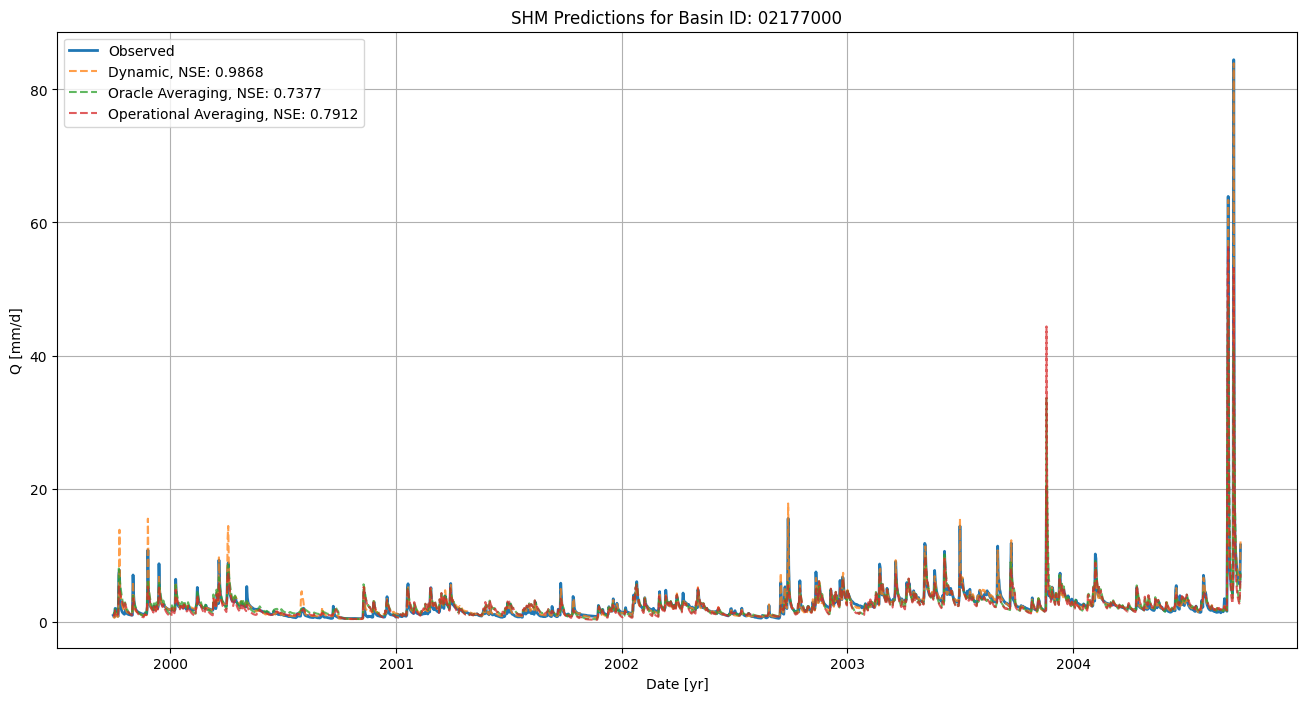

In [12]:
fig, ax = plt.subplots(figsize=(16,8), nrows=1, ncols=1)
dates = dynamic_shm_predictions[basin]["1D"]["xr"]["datetime"]
observed = dynamic_shm_predictions[basin]["1D"]["xr"]["QObs(mm/d)_obs"]
dynamic_nse = dynamic_shm_predictions[basin]["1D"]["NSE"]
oracle_nse = oracle_shm_predictions[basin]["1D"]["NSE"]
operational_nse = operational_shm_predictions[basin]["1D"]["NSE"]

ax.plot(dates,
        observed,
        label="Observed",
        linewidth=2)

ax.plot(dates,
        dynamic_shm_predictions[basin]["1D"]["xr"]["QObs(mm/d)_sim"],
        label=f"{prediction_mode_keys[0]}, NSE: {dynamic_nse:.4f}",
        linestyle="--",
        alpha=0.75)

ax.plot(dates,
        oracle_shm_predictions[basin]["1D"]["xr"]["QObs(mm/d)_sim"],
        label=f"{prediction_mode_keys[1]}, NSE: {oracle_nse:.4f}",
        linestyle="--",
        alpha=0.75)   

ax.plot(dates,
        operational_shm_predictions[basin]["1D"]["xr"]["QObs(mm/d)_sim"],
        label=f"{prediction_mode_keys[2]}, NSE: {operational_nse:.4f}",
        linestyle="--",
        alpha=0.75)

ax.set_ylabel("Q [mm/d]")
ax.set_xlabel("Date [yr]")
ax.set_title(f"SHM Predictions for Basin ID: {basin}")
ax.legend()
ax.grid()

## Plotting SHM Conceptual Parameters For All Modes

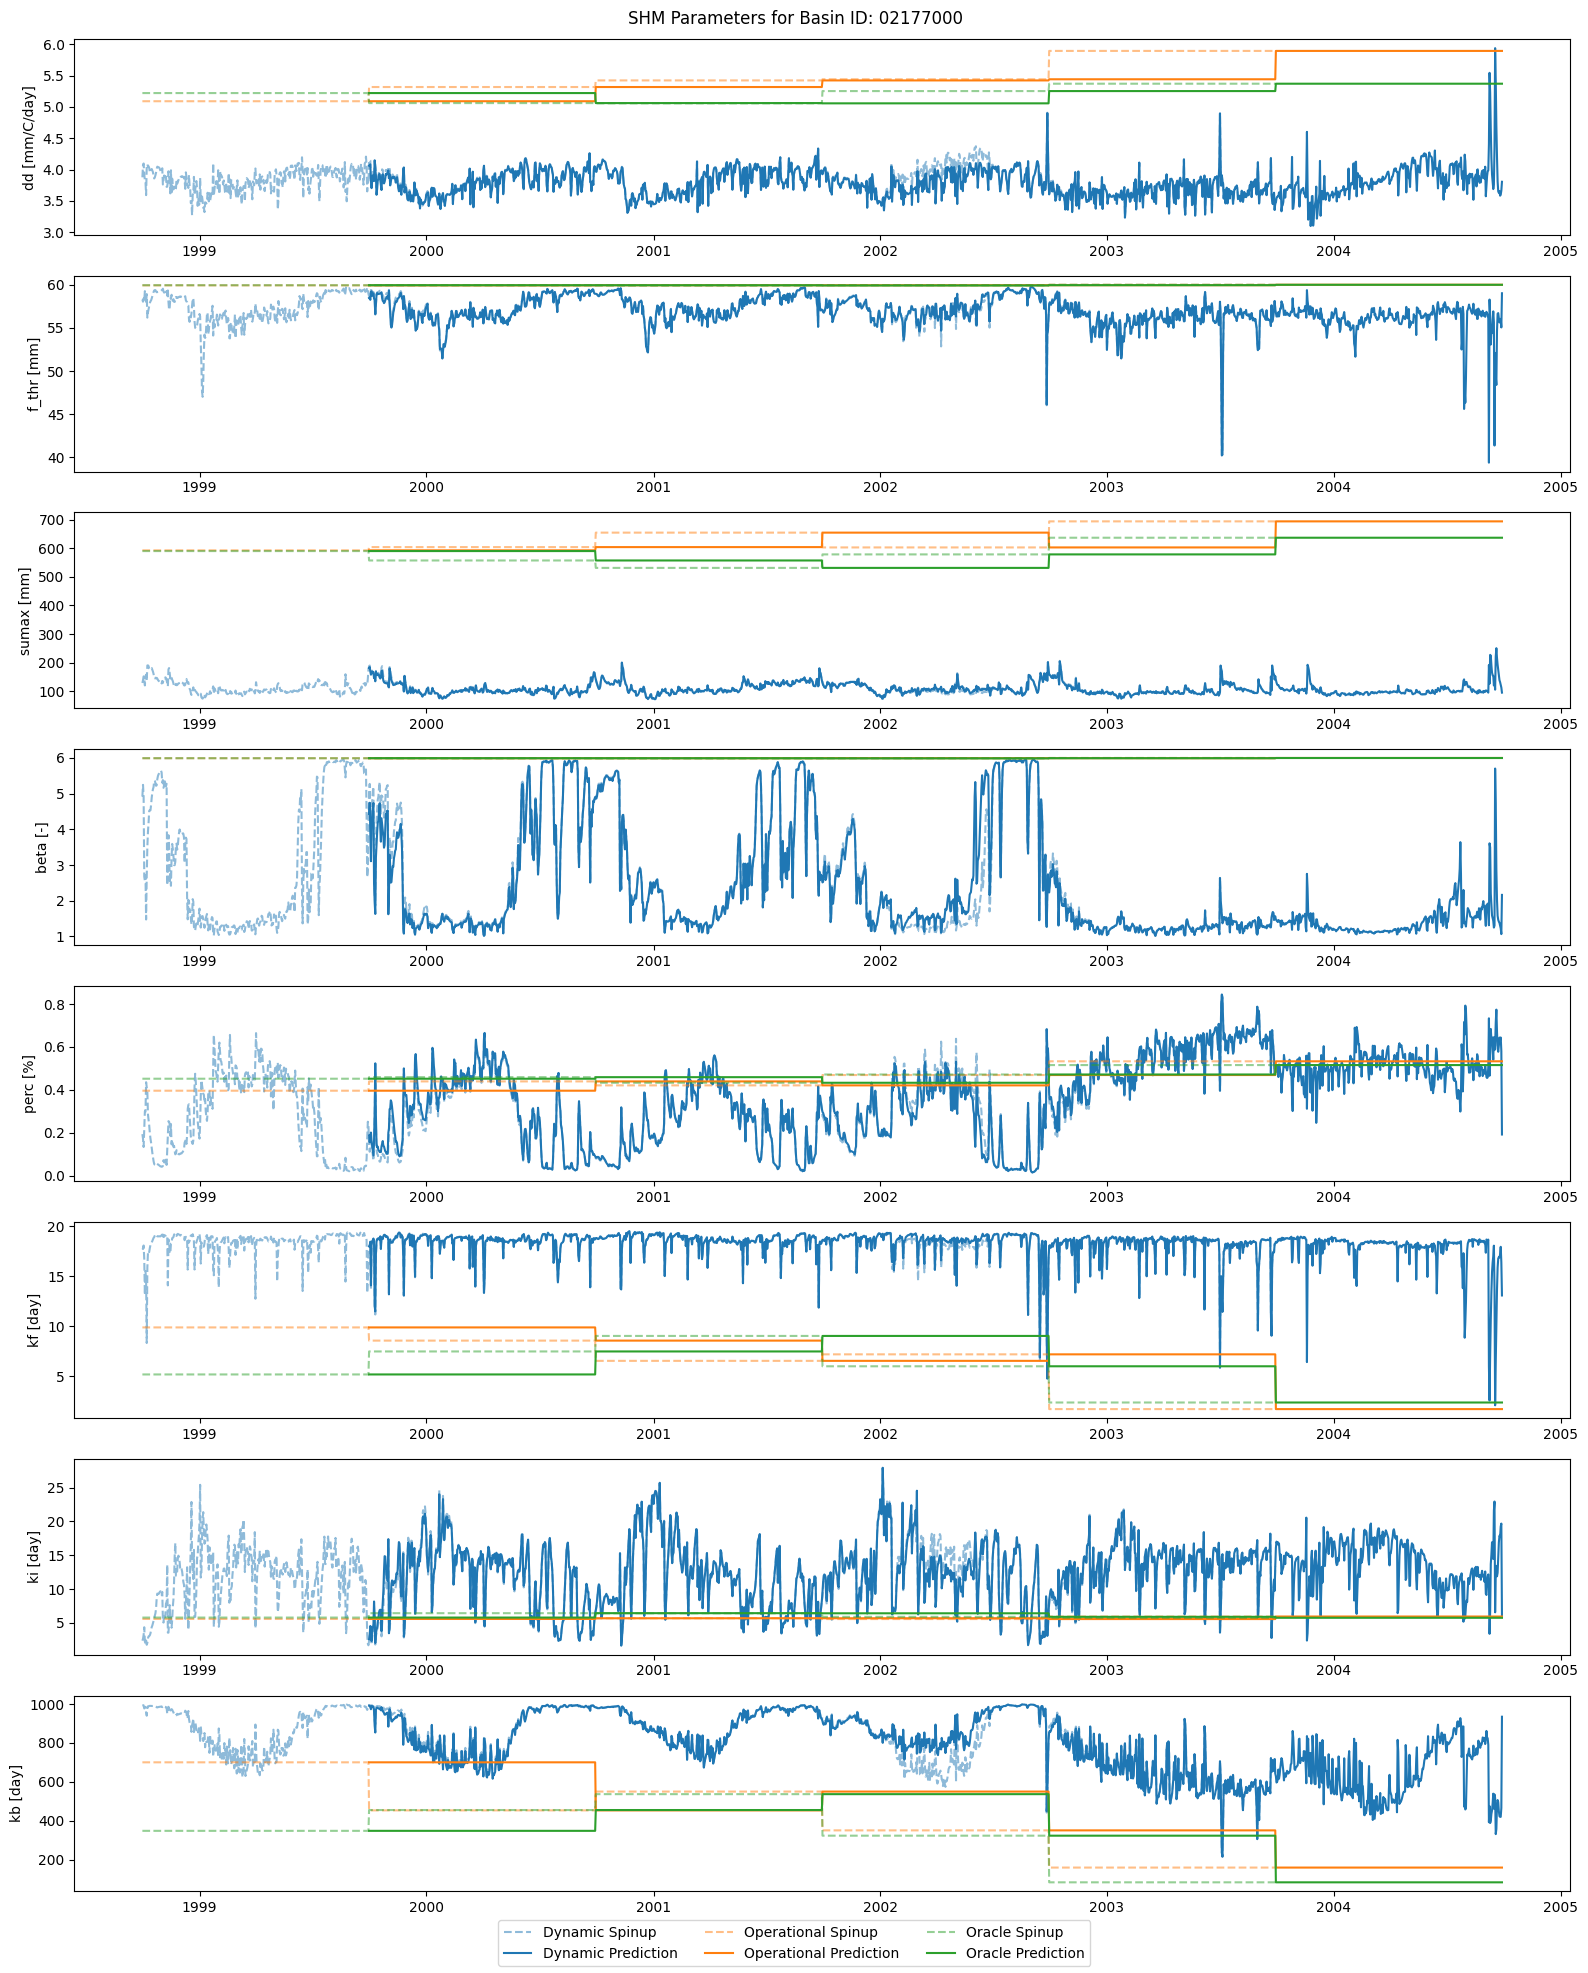

In [13]:
param_unit_keys = ['[mm/C/day]', '[mm]', '[mm]', '[-]', '[%]', '[day]', '[day]', '[day]']
param_dates = dynamic_shm_all_output['datetime']

fig, ax = plt.subplots(figsize=(16,2.5*len(param_keys)), nrows=len(param_keys), ncols=1)
for i, param_interest in enumerate(param_keys):
    label_dynamic_spinup = "Dynamic Spinup" if i == 0 else None
    label_dynamic_prediction = "Dynamic Prediction" if i == 0 else None
    label_operational_spinup = "Operational Spinup" if i == 0 else None
    label_operational_prediction = "Operational Prediction" if i == 0 else None
    label_oracle_spinup = "Oracle Spinup" if i == 0 else None
    label_oracle_prediction = "Oracle Prediction" if i == 0 else None
    ax[i].plot(param_dates, dynamic_shm_all_output[basin]["spinup_parameters"][param_interest], 
               color="tab:blue", label=label_dynamic_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, dynamic_shm_all_output[basin]["prediction_parameters"][param_interest], 
               color="tab:blue", label=label_dynamic_prediction, linestyle='-')
    ax[i].plot(param_dates, operational_shm_all_output[basin]["spinup_parameters"][param_interest],
               color="tab:orange", label=label_operational_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, operational_shm_all_output[basin]["prediction_parameters"][param_interest],
               color="tab:orange", label=label_operational_prediction, linestyle='-')
    ax[i].plot(param_dates, oracle_shm_all_output[basin]["spinup_parameters"][param_interest],
               color="tab:green", label=label_oracle_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, oracle_shm_all_output[basin]["prediction_parameters"][param_interest],
               color="tab:green", label=label_oracle_prediction, linestyle='-')
    ax[i].set_ylabel(f"{param_interest} {param_unit_keys[i]}")
fig.legend(loc="lower center", ncol=3)
fig.suptitle(f"SHM Parameters for Basin ID: {basin}")
plt.tight_layout(rect=[0, 0.02, 1, 0.99])

## Plotting SHM Internal States For All Modes

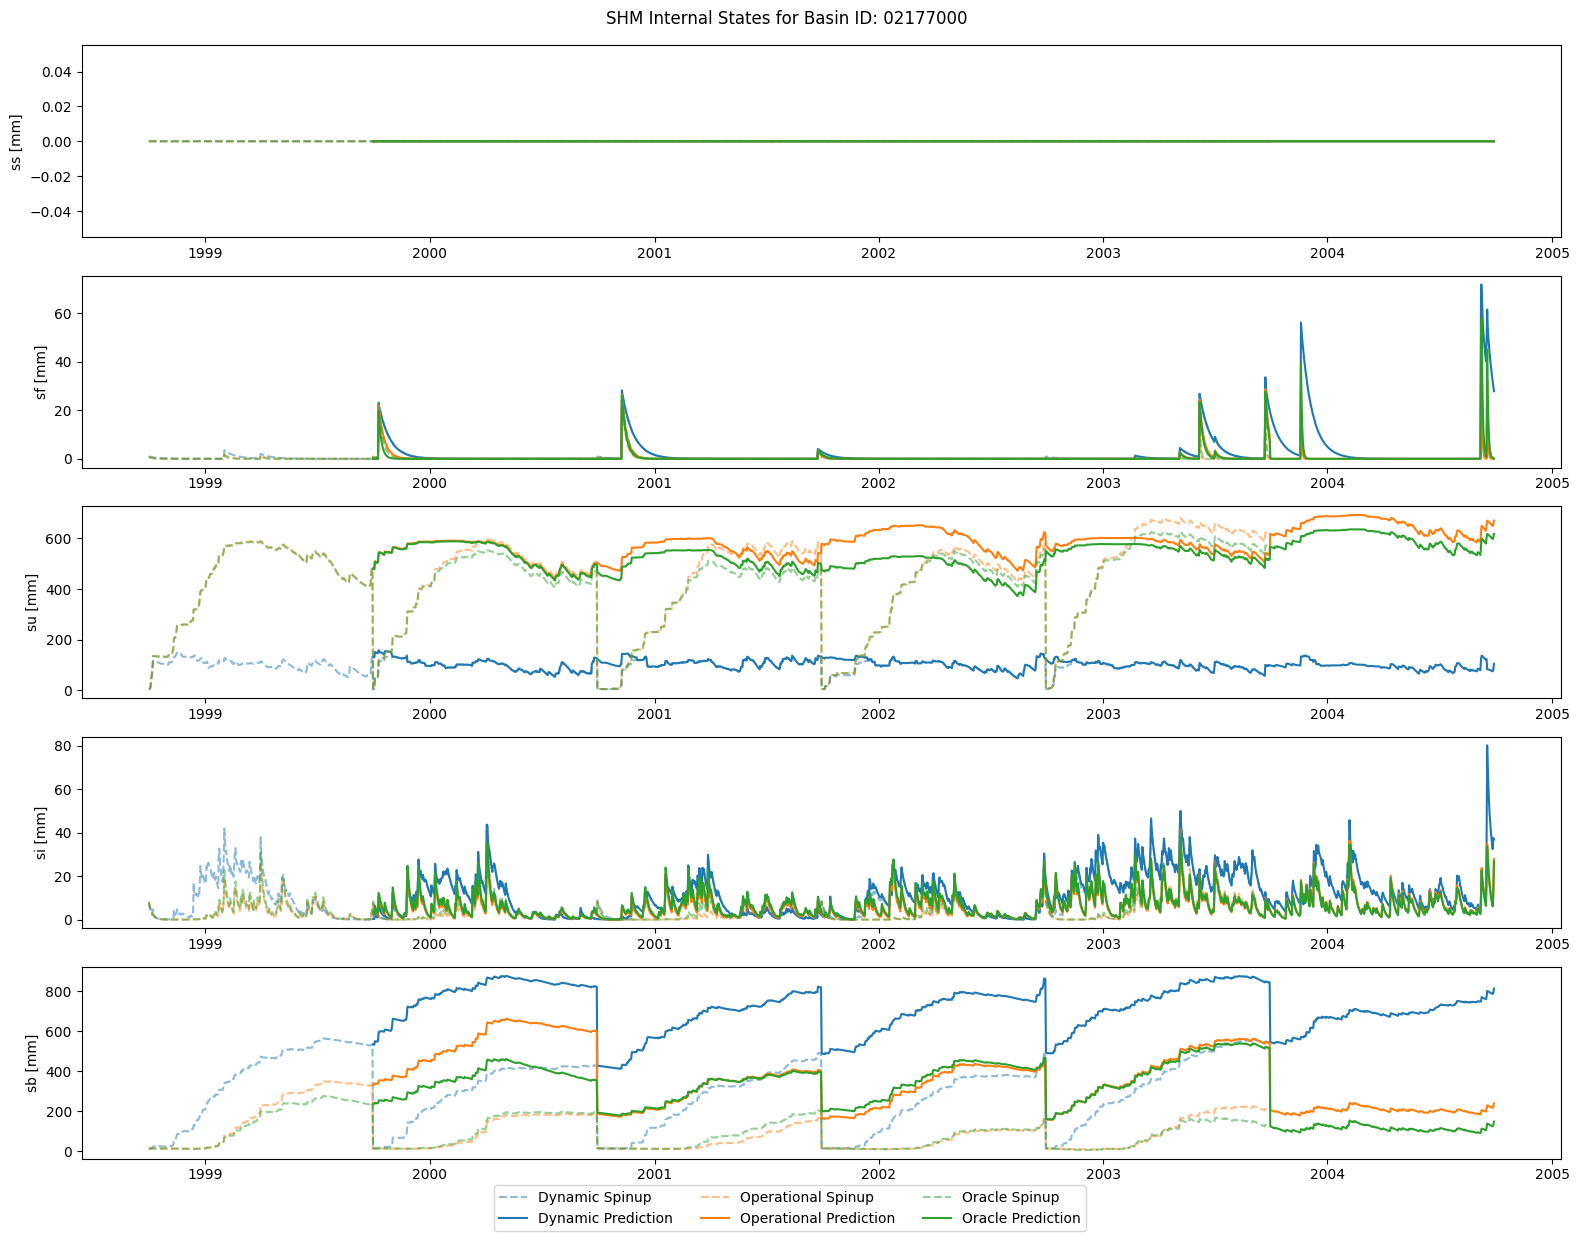

In [50]:
state_dates = dynamic_shm_all_output['datetime']

fig, ax = plt.subplots(figsize=(16,2.5*len(state_keys)), nrows=len(state_keys), ncols=1)
for i, state_interest in enumerate(state_keys):
    label_dynamic_spinup = "Dynamic Spinup" if i == 0 else None
    label_dynamic_prediction = "Dynamic Prediction" if i == 0 else None
    label_operational_spinup = "Operational Spinup" if i == 0 else None
    label_operational_prediction = "Operational Prediction" if i == 0 else None
    label_oracle_spinup = "Oracle Spinup" if i == 0 else None
    label_oracle_prediction = "Oracle Prediction" if i == 0 else None
    ax[i].plot(state_dates, dynamic_shm_all_output[basin]["spinup_internal_states"][state_interest], 
               color="tab:blue", label=label_dynamic_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(state_dates, dynamic_shm_all_output[basin]["prediction_internal_states"][state_interest], 
               color="tab:blue", label=label_dynamic_prediction, linestyle='-')
    ax[i].plot(state_dates, operational_shm_all_output[basin]["spinup_internal_states"][state_interest],
               color="tab:orange", label=label_operational_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(state_dates, operational_shm_all_output[basin]["prediction_internal_states"][state_interest],
               color="tab:orange", label=label_operational_prediction, linestyle='-')
    ax[i].plot(state_dates, oracle_shm_all_output[basin]["spinup_internal_states"][state_interest],
               color="tab:green", label=label_oracle_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(state_dates, oracle_shm_all_output[basin]["prediction_internal_states"][state_interest],
               color="tab:green", label=label_oracle_prediction, linestyle='-')
    ax[i].set_ylabel(f"{state_interest} [mm]")
fig.legend(loc="lower center", ncol=3)
fig.suptitle(f"SHM Internal States for Basin ID: {basin}")
plt.tight_layout(rect=[0, 0.03, 1, 0.99])